# Kramer+2022 HPLC dataset

In [39]:
# imports
from importlib import reload
from importlib.resources import files
import os
import numpy as np

from io import StringIO

from scipy.optimize import curve_fit
from sklearn import decomposition

import xarray

import pandas
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d

from ocpy.hydrolight import loisel23
from ocpy.utils import plotting as oc_plotting

from cnmf.oceanography import utils as co_utils
from cnmf import nmf_imaging
from cnmf import stats as cnmf_stats

In [31]:
%matplotlib ipympl

# Load up

In [18]:
kramer_file = os.path.join(os.getenv('OS_COLOR'), 'data', 'Kramer', 'Kramer-etal_2021.tab')

In [9]:
# Read the file
with open(kramer_file, 'r') as file:
    content = file.read()

# Split the content into description and data
parts = content.split('*/')

# Extract the description
description = parts[0].strip('/*').strip()

# Read the tab-separated data into a pandas DataFrame
df = pandas.read_csv(StringIO(parts[1].strip()), sep='\t')

# Print the description and the first few rows of the DataFrame
#print("Description:")
#print(description)
#print("\nData:")
df.head()

,Campaign,URL ref,PI,Date/Time,Latitude,Longitude,Depth water [m] (min),Depth water [m] (max),TChl a [µg/l] (High Performance Liquid Chrom...),Chl b + DV Chl b [µg/l] (High Performance Liquid Chrom...),...,Rrs_691 [1/sr] (Hyperspectral radiometer),Rrs_692 [1/sr] (Hyperspectral radiometer),Rrs_693 [1/sr] (Hyperspectral radiometer),Rrs_694 [1/sr] (Hyperspectral radiometer),Rrs_695 [1/sr] (Hyperspectral radiometer),Rrs_696 [1/sr] (Hyperspectral radiometer),Rrs_697 [1/sr] (Hyperspectral radiometer),Rrs_698 [1/sr] (Hyperspectral radiometer),Rrs_699 [1/sr] (Hyperspectral radiometer),Rrs_700 [1/sr] (Hyperspectral radiometer)
0,ANT-XXIV/4 (PS71),https://doi.org/10.1594/PANGAEA.847820,"Bracher, Astrid",2008-04-23T17:15:00,-39.6444,-50.0232,0,0,0.329,0.045,...,0.000060,0.000057,0.000054,0.000050,0.000046,0.000041,0.000037,0.000033,0.000030,0.000028
1,ANT-XXIV/4 (PS71),https://doi.org/10.1594/PANGAEA.847820,"Bracher, Astrid",2008-04-25T16:19:00,-33.5368,-42.1789,0,0,0.342,0.025,...,0.000020,0.000019,0.000017,0.000015,0.000013,0.000011,0.000009,0.000007,0.000006,0.000006
2,ANT-XXIV/4 (PS71),https://doi.org/10.1594/PANGAEA.847820,"Bracher, Astrid",2008-04-29T15:18:00,-19.1777,-32.7467,0,0,0.087,0.003,...,0.000041,0.000040,0.000039,0.000037,0.000035,0.000031,0.000027,0.000023,0.000020,0.000018
3,ANT-XXIV/4 (PS71),https://doi.org/10.1594/PANGAEA.847820,"Bracher, Astrid",2008-05-03T14:14:00,-3.7014,-26.6022,0,0,0.169,0.005,...,0.000019,0.000020,0.000020,0.000020,0.000020,0.000019,0.000017,0.000015,0.000014,0.000012
4,ANT-XXIV/4 (PS71),https://doi.org/10.1594/PANGAEA.847820,"Bracher, Astrid",2008-05-09T13:31:00,19.9938,-20.8246,0,0,0.973,0.097,...,0.000073,0.000067,0.000062,0.000057,0.000053,0.000048,0.000044,0.000041,0.000037,0.000034


## Parse a bit

In [11]:
df.keys()

Index(['Campaign', 'URL ref', 'PI', 'Date/Time', 'Latitude', 'Longitude',
       'Depth water [m] (min)', 'Depth water [m] (max)',
       'TChl a [µg/l] (High Performance Liquid Chrom...)',
       'Chl b + DV Chl b [µg/l] (High Performance Liquid Chrom...)',
       ...
       'Rrs_691 [1/sr] (Hyperspectral radiometer)',
       'Rrs_692 [1/sr] (Hyperspectral radiometer)',
       'Rrs_693 [1/sr] (Hyperspectral radiometer)',
       'Rrs_694 [1/sr] (Hyperspectral radiometer)',
       'Rrs_695 [1/sr] (Hyperspectral radiometer)',
       'Rrs_696 [1/sr] (Hyperspectral radiometer)',
       'Rrs_697 [1/sr] (Hyperspectral radiometer)',
       'Rrs_698 [1/sr] (Hyperspectral radiometer)',
       'Rrs_699 [1/sr] (Hyperspectral radiometer)',
       'Rrs_700 [1/sr] (Hyperspectral radiometer)'],
      dtype='object', length=336)

In [29]:
wave = []
wkeys = []
Rrs = []
for key in df.keys():
    if key[:3] == 'Rrs':
        iwave = int(key[4:7])
        wave.append(float(iwave))
        wkeys.append(key)
        #
        Rrs.append(df[key].values)
# Arrays
Rrs = np.array(Rrs).T
wave = np.array(wave)
wave[::4]

array([400., 404., 408., 412., 416., 420., 424., 428., 432., 436., 440.,
       444., 448., 452., 456., 460., 464., 468., 472., 476., 480., 484.,
       488., 492., 496., 500., 504., 508., 512., 516., 520., 524., 528.,
       532., 536., 540., 544., 548., 552., 556., 560., 564., 568., 572.,
       576., 580., 584., 588., 592., 596., 600., 604., 608., 612., 616.,
       620., 624., 628., 632., 636., 640., 644., 648., 652., 656., 660.,
       664., 668., 672., 676., 680., 684., 688., 692., 696., 700.])

In [30]:
Rrs.shape

(145, 301)

## Check one

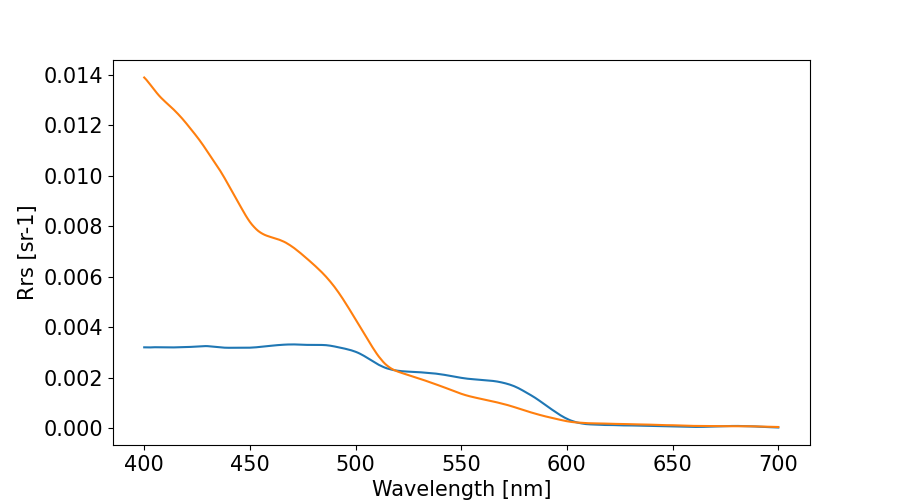

In [37]:
fig = plt.figure(figsize=(9,5))
plt.clf()
ax = plt.gca()
ax.plot(wave, Rrs[0])
ax.plot(wave, Rrs[50])
# Label
ax.set_ylabel('Rrs [sr-1]')
ax.set_xlabel('Wavelength [nm]')
#
#ax.set_xlim(0,10.)
oc_plotting.set_fontsize(ax, 15)
#
plt.show()

# PCA

## Fit

In [40]:
n_components = 10
pca_fit = decomposition.PCA(n_components=n_components).fit(Rrs)

## Variance Explained

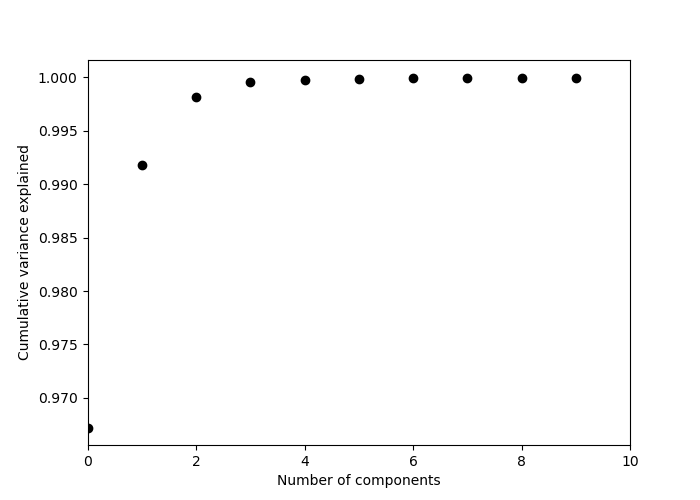

In [41]:
fig = plt.figure(figsize=(7,5))
plt.clf()
ax = plt.gca()
ax.plot(np.cumsum(pca_fit.explained_variance_ratio_), 'ok')
# Label
ax.set_ylabel('Cumulative variance explained')
ax.set_xlabel('Number of components')
#
ax.set_xlim(0,10.)
#
plt.show()

----

# NMF me

## Scale

In [42]:
i400 = np.argmin(np.abs(wave-400.))
i600 = np.argmin(np.abs(wave-600.))

In [43]:
scaled_Rrs = (Rrs * 1e4)[:,i400:i600]
cutwave = wave[i400:i600]

In [44]:
scaled_Rrs.shape

(145, 200)

## Prep

In [45]:
new_spec, mask, err = co_utils.prep(scaled_Rrs, sigma=0.1)

In [46]:
new_spec.shape

(145, 200, 1)

## Check

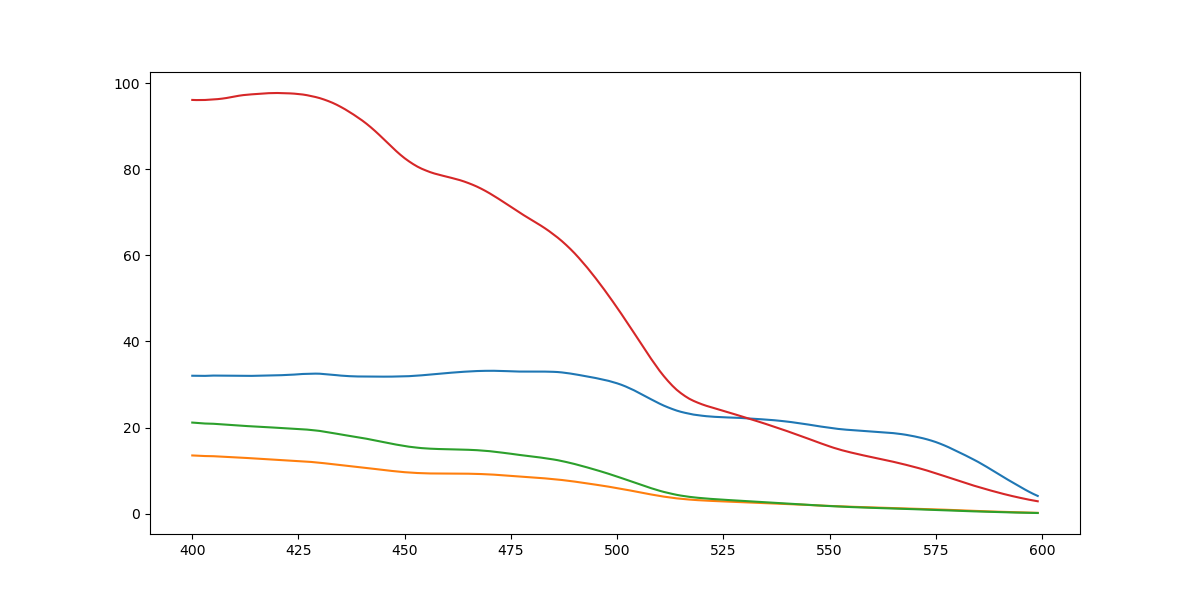

In [48]:
fig = plt.figure(figsize=(12,6))
ax = plt.gca()

ax.plot(cutwave, new_spec[0,:])
ax.plot(cutwave, new_spec[10,:])
ax.plot(cutwave, new_spec[20,:])
ax.plot(cutwave, new_spec[100,:])

if False:
    ii = 0
    sns.lineplot(x=cutwave, y=M[ii]*10000, color='k',
                 label=r'$W_'+f'{ii+1}'+'$',
                 ax=ax, lw=2)#

#
plt.show()


## Do it

## REMEMBER TO DELETE THE FILES FIRST!!!

### rm Kramer_scaledRrs_co*

In [53]:
N_NMF = 4
outroot = 'Kramer_scaledRrs'
normalize = True
#
reload(nmf_imaging)
comps = nmf_imaging.NMFcomponents(
    ref=new_spec, mask=mask, ref_err=err,
    n_components=N_NMF,
    path_save=outroot, oneByOne=False,
    normalize=normalize,
    seed=12345, verbose=True)

Building components NOT one by one... If you want the one-by-one method (suggested), please set oneByOne = True.
Current Chi2=11742.3209, Previous Chi2=287292.3099, Change=95.9128% @ niters=0
Current Chi2=464.2955, Previous Chi2=471.2895, Change=1.4840% @ niters=50
Current Chi2=257.3718, Previous Chi2=260.4729, Change=1.1906% @ niters=100
Current Chi2=158.3434, Previous Chi2=159.4629, Change=0.7021% @ niters=150
Current Chi2=125.6739, Previous Chi2=126.0092, Change=0.2661% @ niters=200
Current Chi2=116.2325, Previous Chi2=116.3335, Change=0.0868% @ niters=250
Current Chi2=112.9587, Previous Chi2=113.0017, Change=0.0381% @ niters=300
Current Chi2=111.3580, Previous Chi2=111.3825, Change=0.0220% @ niters=350
Current Chi2=110.3361, Previous Chi2=110.3537, Change=0.0160% @ niters=400
Current Chi2=109.5508, Previous Chi2=109.5649, Change=0.0128% @ niters=450
Current Chi2=108.9243, Previous Chi2=108.9356, Change=0.0103% @ niters=500
Current Chi2=108.4321, Previous Chi2=108.4407, Change=0.007

/home/xavier/Projects/Oceanography/python/cnmf/cnmf/nmf_imaging.py:192: RuntimeWarning: invalid value encountered in divide
  components = (components.T/np.sqrt(np.nansum(components**2, axis = (1, 2))).T).T


# Examine

In [54]:
M = np.load(outroot+'_comp.npy').T
coeff = np.load(outroot+'_coef.npy').T

In [55]:
M.shape

(4, 200)

## Plot

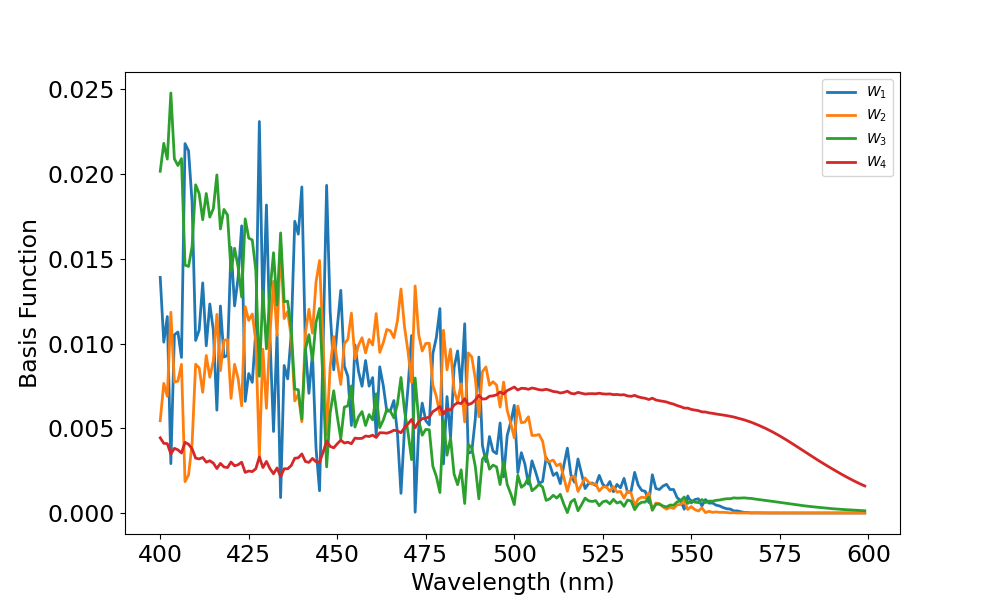

In [57]:
fig = plt.figure(figsize=(10,6))
ax = plt.gca()
#
for ii in range(N_NMF):
#for ii in range(1):
    # Step plot
    sns.lineplot(x=cutwave, y=M[ii],
                 label=r'$W_'+f'{ii+1}'+'$',
                 ax=ax, lw=2)#
# Pretty me up
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Basis Function')
oc_plotting.set_fontsize(ax, 17.)
#
plt.savefig('NMF_on_Rrs.png', dpi=300)
plt.show()

# Stats

In [28]:
evar_i = cnmf_stats.evar_computation(scaled_Rrs, coeff, M)

In [29]:
evar_i

0.9986883753909981